# Силаев Андрей ИУ5-22М, Вариант 13

Задачи 13, 33

## Задачи
Для набора данных проведите нормализацию для одного (произвольного) числового признака с использованием функции "обратная зависимость - 1 / X".
Для набора данных проведите процедуру отбора признаков (feature selection). Используйте метод обертывания (wrapper method), алгоритм полного перебора (exhaustive feature selection).

Для студентов групп ИУ5-22М, ИУ5И-22М - для произвольной колонки данных построить гистограмму.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import sklearn

In [2]:
data = pd.read_csv("Spotify-2000.csv")
%matplotlib inline

In [3]:
data.head(10)

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59
5,6,The Road Ahead (Miles Of The Unknown),City To City,alternative pop rock,2004,99,46,54,-9,14,14,247,0,2,45
6,7,She Will Be Loved,Maroon 5,pop,2002,102,71,71,-6,13,54,257,6,3,74
7,8,Knights of Cydonia,Muse,modern rock,2006,137,96,37,-5,12,21,366,0,14,69
8,9,Mr. Brightside,The Killers,modern rock,2004,148,92,36,-4,10,23,223,0,8,77
9,10,Without Me,Eminem,detroit hip hop,2002,112,67,91,-3,24,66,290,0,7,82


In [4]:
data_features = list(zip(
# признаки
[i for i in data.columns],
zip(
    # типы колонок
    [str(i) for i in data.dtypes],
    # проверим есть ли пропущенные значения
    [i for i in data.isnull().sum()]
)))
# Признаки с типом данных и количеством пропусков
data_features

[('Index', ('int64', 0)),
 ('Title', ('object', 0)),
 ('Artist', ('object', 0)),
 ('Top Genre', ('object', 0)),
 ('Year', ('int64', 0)),
 ('Beats Per Minute (BPM)', ('int64', 0)),
 ('Energy', ('int64', 0)),
 ('Danceability', ('int64', 0)),
 ('Loudness (dB)', ('int64', 0)),
 ('Liveness', ('int64', 0)),
 ('Valence', ('int64', 0)),
 ('Length (Duration)', ('object', 0)),
 ('Acousticness', ('int64', 0)),
 ('Speechiness', ('int64', 0)),
 ('Popularity', ('int64', 0))]

## Нормализация, построение гистограммы

In [16]:
def diagnostic_plots(df, variable):
    plt.figure(figsize=(15,6))
    # гистограмма
    plt.subplot(1, 2, 1)
    df[variable].hist(bins=30)
    ## Q-Q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.show()

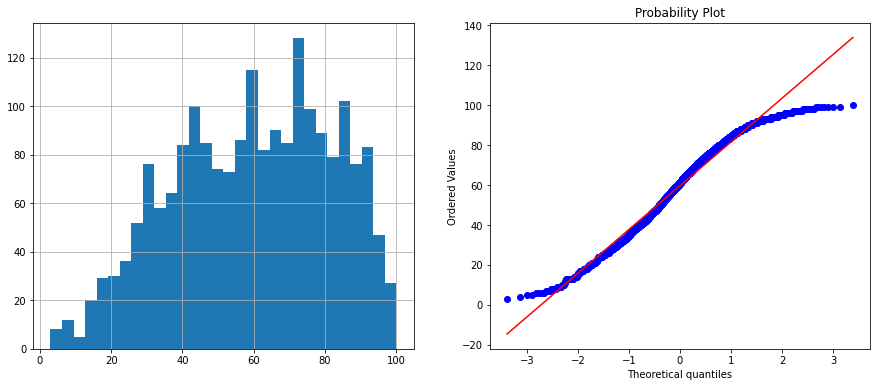

In [23]:
diagnostic_plots(data, 'Energy')

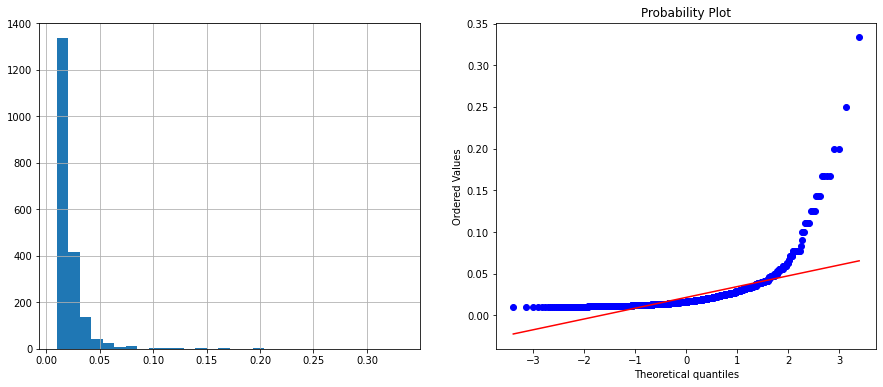

In [24]:
# Результат такой нормализации не очень хороший, вероятно лучше использовать другой вид нормализации.
data['Energy_reciprocal'] = 1 / (data['Energy']) 
diagnostic_plots(data, 'Energy_reciprocal')

##  Метод обертывания (wrapper method) с полным перебором

In [139]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)

In [140]:
X = data.drop(columns = ['Title','Artist','Top Genre','Energy','Index', 'Length (Duration)', 'Energy_reciprocal', 'Year'])
y = data['Year']

feature_names = [i for i in X.columns]
feature_names

['Beats Per Minute (BPM)',
 'Danceability',
 'Loudness (dB)',
 'Liveness',
 'Valence',
 'Acousticness',
 'Speechiness',
 'Popularity']

In [150]:
efs1 = EFS(knn, 
           min_features=2,
           max_features=4,
           scoring='neg_mean_absolute_error',
           print_progress=True,
           cv=5)

efs1 = efs1.fit(X, y, custom_feature_names=feature_names)

print('Best accuracy score: %.2f' % efs1.best_score_)
print('Best subset (indices):', efs1.best_idx_)
print('Best subset (corresponding names):', efs1.best_feature_names_)

Features: 154/154

Best accuracy score: -15.61
Best subset (indices): (1, 2, 4, 7)
Best subset (corresponding names): ('Danceability', 'Loudness (dB)', 'Valence', 'Popularity')
